# **INGENIERÍA DEL DATO**

### **CARGA DE DRIVE**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Se fija el estilo para todas las gráficas del proyecto.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set_theme(style="whitegrid", context="paper")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#333333",
    "grid.color": "#D9D9D9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6
})

### **CARGA DE DATOS**
Cada una de las variables que componen el modelo estaba recogida en un documento .csv, por lo que se han tenido que cargar todos los documentos y se han combinado teniendo en cuenta de que para cada observación de cada una de las variables se tenía el dato de la Comunidad Autonoma y del Periodo (Año) a los cuales se refería.

In [3]:
# Carga de las rutas
import pandas as pd

ruta_base = "/content/drive/MyDrive/DATOS_TFG_LIMPIOS/"

df_ingresos = pd.read_csv(ruta_base + "Ingresos_Hospitalarios.csv")
df_aguas = pd.read_csv(ruta_base + "Volumen_Aguas_Tratadas.csv")
df_renta = pd.read_csv(ruta_base + "Renta_anual.csv")
df_residuos = pd.read_csv(ruta_base + "Residuos.csv")
df_calidad = pd.read_csv(ruta_base + "Calidad_Vida_Global.csv")
df_poblacion = pd.read_csv(ruta_base + "Cifras_Poblacion.csv")
df_defunciones = pd.read_csv(ruta_base + "Defunciones.csv")
df_dist_ingresos = pd.read_csv(ruta_base + "DesigualdadDistribucionIngresos.csv")
df_emisiones = pd.read_csv(ruta_base + "EmisionesGEI.csv")
df_cifras_negocio = pd.read_csv(ruta_base + "IndiceCifrasNegocio.csv")
df_prod_industrial = pd.read_csv(ruta_base + "IndiceProduccionIndustrial.csv")

In [4]:
# Combinación .csv
df_merged = df_ingresos.merge(df_aguas, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_renta, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_residuos, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_calidad, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_poblacion, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_defunciones, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_dist_ingresos, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_emisiones, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_cifras_negocio, on=["Comunidad Autonoma", "Periodo"], how="outer") \
                       .merge(df_prod_industrial, on=["Comunidad Autonoma", "Periodo"], how="outer")

In [5]:
df_merged = df_merged.sort_values(["Comunidad Autonoma", "Periodo"]).reset_index(drop=True)

In [6]:
print(df_merged.shape)

print(df_merged.dtypes)

(1846, 13)
Comunidad Autonoma               object
Periodo                           int64
Ingresos_Hospitalarios          float64
Volumen_Agua_Tratada            float64
Renta_Anual                     float64
Residuos                        float64
Calidad_Vida                    float64
Poblacion                       float64
Defunciones                     float64
Distribucion_Ingresos           float64
Emisiones_GEI                   float64
Indice_Cifras_Negocio           float64
Indice_Produccion_Industrial    float64
dtype: object


**TRATAMIENTO OUTLIERS**

Con el fin de eliminar los outliers se eliminan los regitros correspondientes a España, Ceuta y Melilla.

In [7]:
df_merged = df_merged[
    ~df_merged["Comunidad Autonoma"].isin(["Espana", "Ceuta", "Melilla", "Extranjero"])
]

**CÁLCULO DE MEDIDAS DE DISPERSIÓN ANTES DE LA IMPUTACIÓN**

El trato de los valores faltantes se realiza mediante una imputación por KNNImputer. Esto se debe prinicpalemtne a que no existe un gran número de registros, por lo que su eliminación conllevaría a un tamaño muy pequeño del conjunto de datos.

In [8]:
# Columnas numéricas
columnas_numericas = df_merged.select_dtypes(include=["float64", "int64"]).columns
print(df_merged[columnas_numericas].describe())

           Periodo  Ingresos_Hospitalarios  Volumen_Agua_Tratada  \
count  1577.000000              187.000000          5.930000e+02   
mean   2004.641725              117.391444          7.789221e+05   
std      15.300471               17.050461          6.041455e+05   
min    1971.000000               90.150000          4.913800e+04   
25%    1993.000000              105.690000          2.986300e+05   
50%    2010.000000              115.040000          5.136160e+05   
75%    2017.000000              127.410000          1.210832e+06   
max    2025.000000              175.670000          2.707751e+06   

        Renta_Anual    Residuos  Calidad_Vida     Poblacion   Defunciones  \
count    765.000000  714.000000    709.000000  1.355000e+03   1168.000000   
mean   26948.284967  145.764566    101.489815  2.570713e+06   6008.678082   
std     8163.159555  180.941229      2.236264  2.305587e+06   5000.110540   
min      243.000000    2.100000     96.383468  2.346200e+05    440.000000   
25

**IMPUTACIÓN POR KNN**

Para tratar los valores faltantes presentes en el dataset se aplicó un método de imputación basado en K-Nearest Neighbors (KNN). Este método estima los valores ausentes utilizando la información de observaciones similares en el conjunto de datos. En este caso se utilizó un modelo con k = 5 vecinos, imputando únicamente las variables numéricas mientras se mantenían sin modificar las columnas identificadoras (Comunidad Autonoma y Periodo). Este enfoque permite preservar las relaciones entre variables y obtener un dataset completo para el análisis posterior.

In [9]:
from sklearn.impute import KNNImputer

columnas_id = ["Comunidad Autonoma", "Periodo"]

columnas_numericas = df_merged.columns.difference(columnas_id)

df_numerico = df_merged[columnas_numericas]

imputer = KNNImputer(n_neighbors=5)

df_imputado = imputer.fit_transform(df_numerico)

df_imputado = pd.DataFrame(df_imputado, columns=columnas_numericas)

df_final = pd.concat(
    [df_merged[columnas_id].reset_index(drop=True),
     df_imputado],
    axis=1
)

Comprobar que se hallan imputado todos los valores y no quede ningún null.

In [10]:
df_final.isnull().sum()

,0
Comunidad Autonoma,0
Periodo,0
Calidad_Vida,0
Defunciones,0
Distribucion_Ingresos,0
Emisiones_GEI,0
Indice_Cifras_Negocio,0
Indice_Produccion_Industrial,0
Ingresos_Hospitalarios,0
Poblacion,0


**CÁLCULO DE MEDIDAS DE DISPERSIÓN DESPUÉS DE LA IMPUTACIÓN**

In [11]:
columnas_numericas = df_final.select_dtypes(include=["float64", "int64"]).columns
print(df_final[columnas_numericas].describe())

           Periodo  Calidad_Vida   Defunciones  Distribucion_Ingresos  \
count  1577.000000   1577.000000   1577.000000            1577.000000   
mean   2004.641725    101.315375   5958.158529              55.859607   
std      15.300471      2.178067   4694.568035               8.799273   
min    1971.000000     96.383468    440.000000              39.000000   
25%    1993.000000     99.674685   2306.000000              49.600000   
50%    2010.000000    101.598860   4230.000000              54.000000   
75%    2017.000000    102.915914   8262.600000              60.600000   
max    2025.000000    106.146702  19307.000000             101.000000   

       Emisiones_GEI  Indice_Cifras_Negocio  Indice_Produccion_Industrial  \
count    1577.000000            1577.000000                   1577.000000   
mean    16658.330247           92696.282815                 102937.643120   
std     12966.125401           31264.074752                  30065.568312   
min       955.000000            12

Comprobar que la distribución de las variables se conserva antes y después de la imputación de valores faltantes

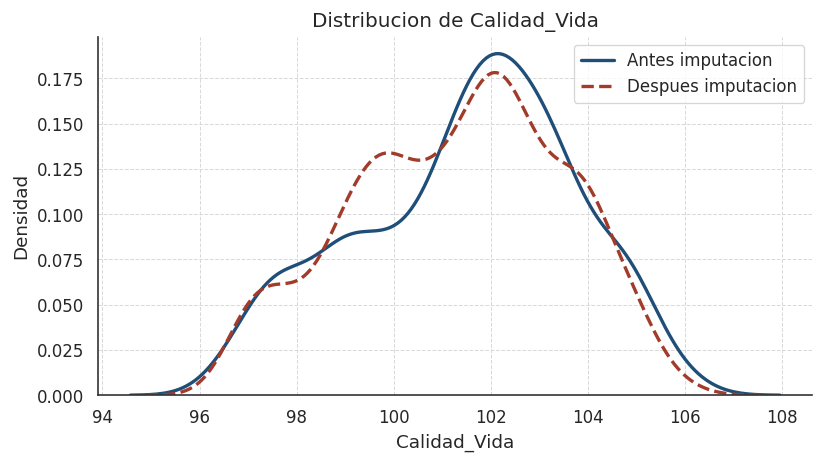

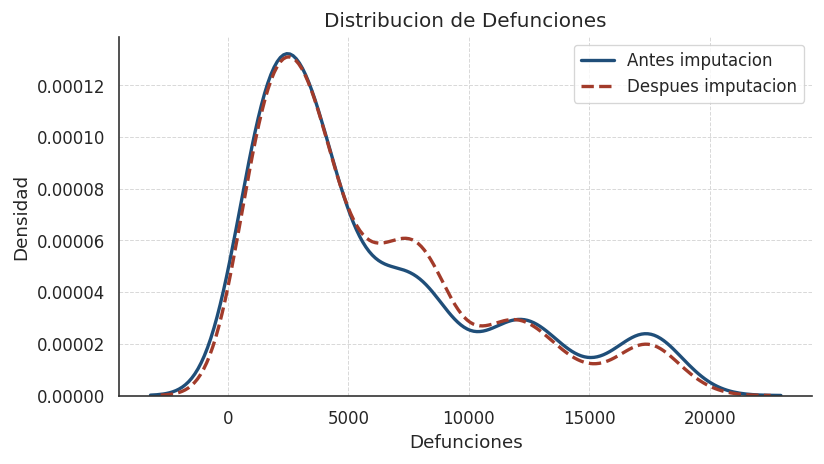

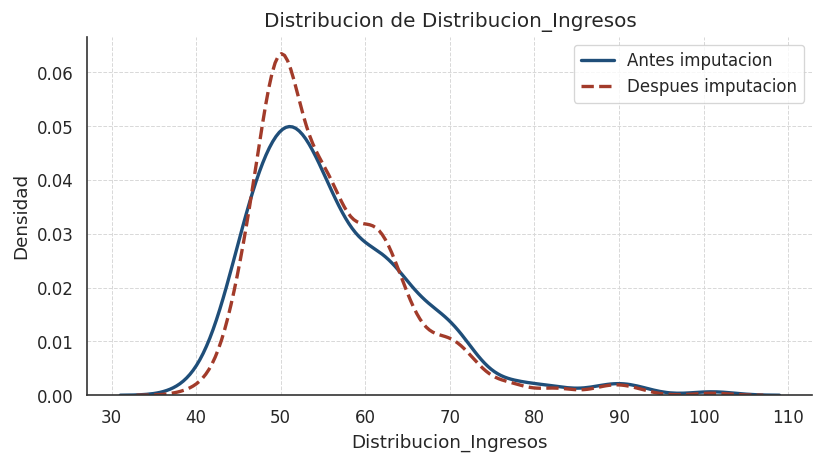

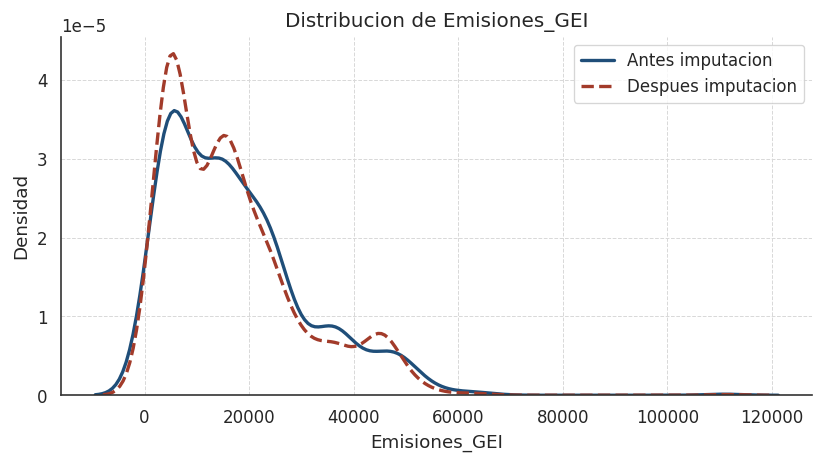

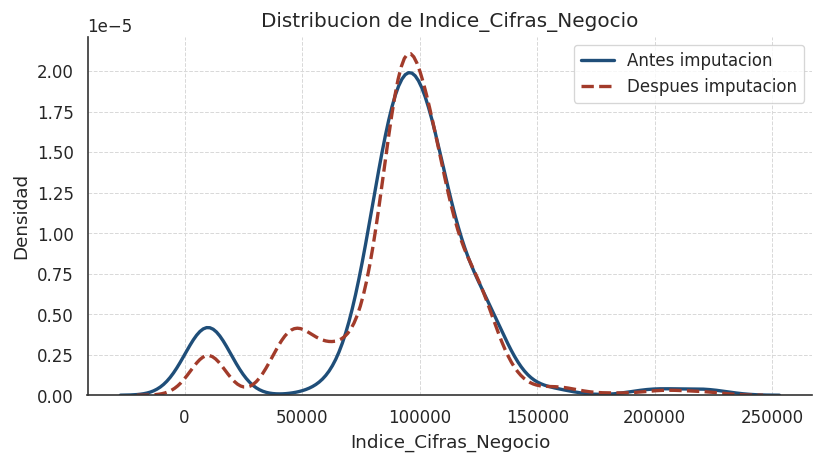

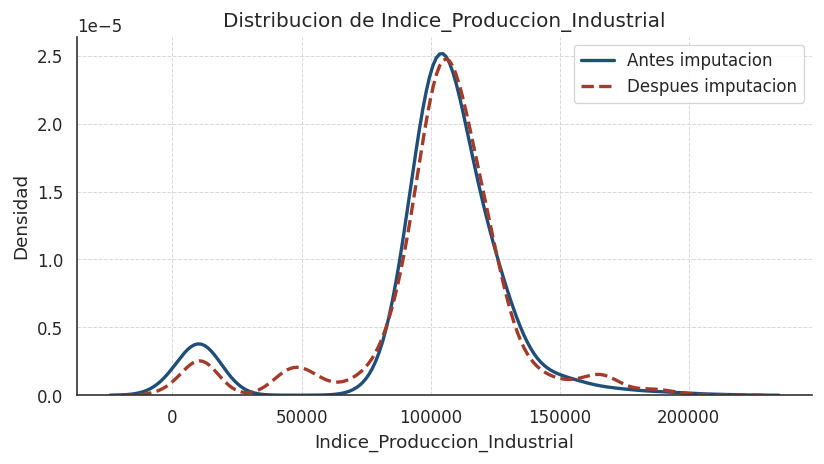

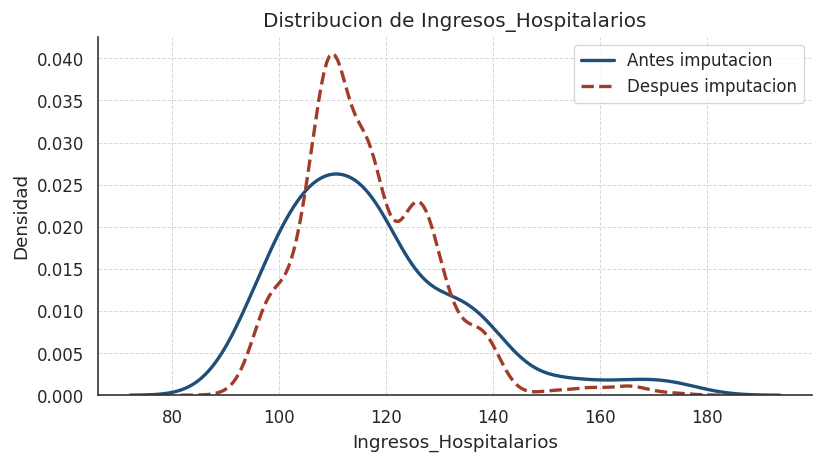

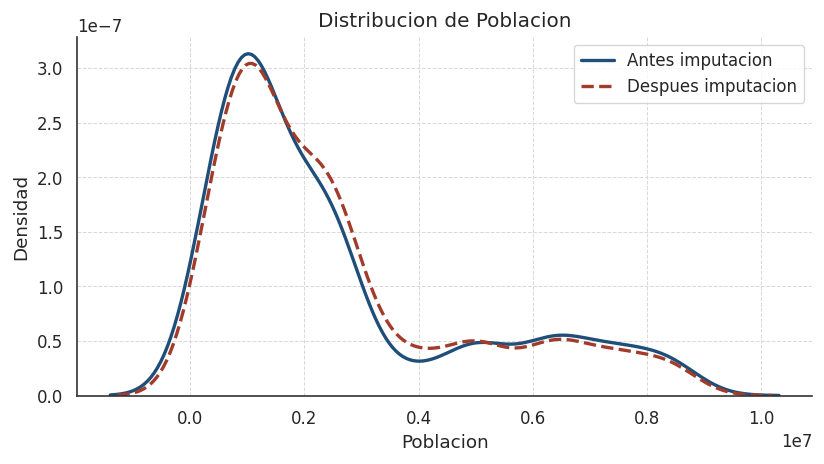

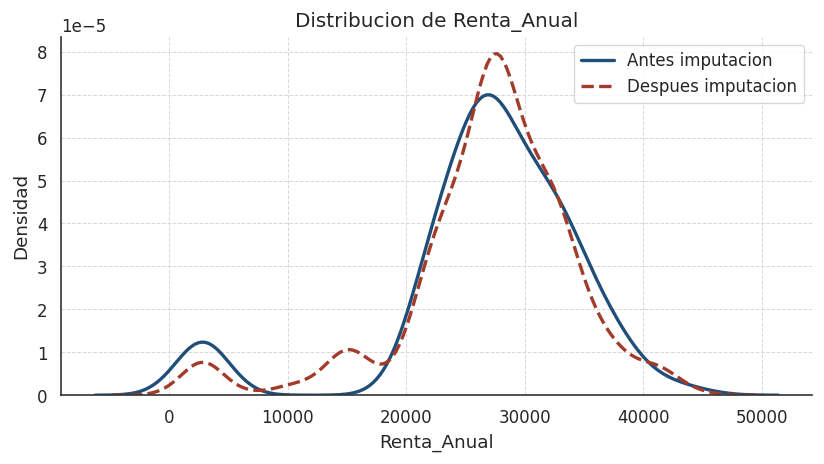

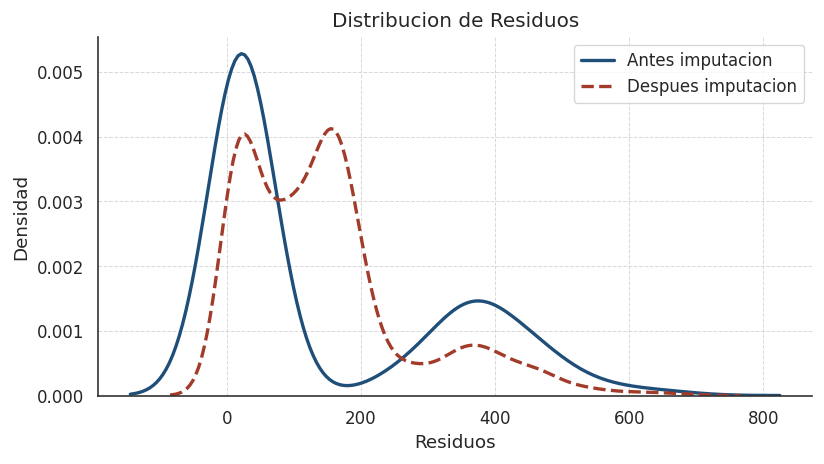

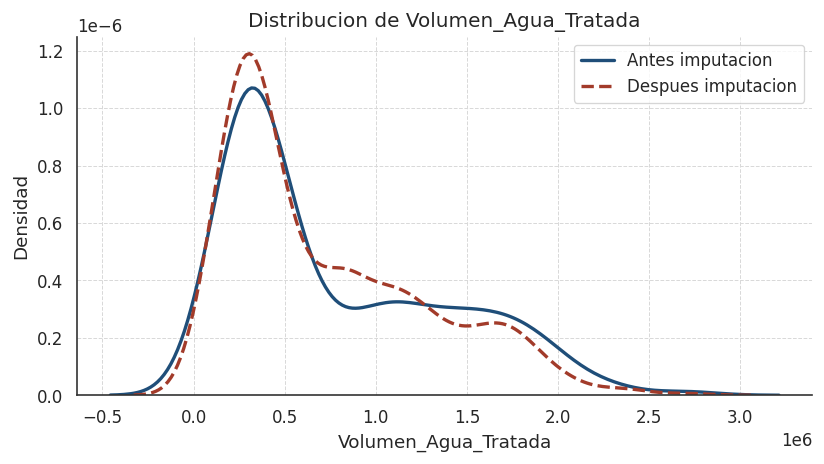

In [12]:
columnas_excluir = ["Comunidad Autonoma", "Periodo"]

columnas_numericas = df_final.columns.difference(columnas_excluir)

for col in columnas_numericas:

    plt.figure(figsize=(7,4))

    sns.kdeplot(
        df_merged[col].dropna(),
        label="Antes imputacion",
        linewidth=2,
        color="#1F4E79"
    )

    sns.kdeplot(
        df_final[col].dropna(),
        label="Despues imputacion",
        linewidth=2,
        linestyle="--",
        color="#A23B2A"
    )

    plt.title(f"Distribucion de {col}")
    plt.xlabel(col)
    plt.ylabel("Densidad")

    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
ruta_salida = "/content/drive/MyDrive/DATOS_TFG_LIMPIOS/Dataset.csv"
df_final.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

**BOXPLOTS**

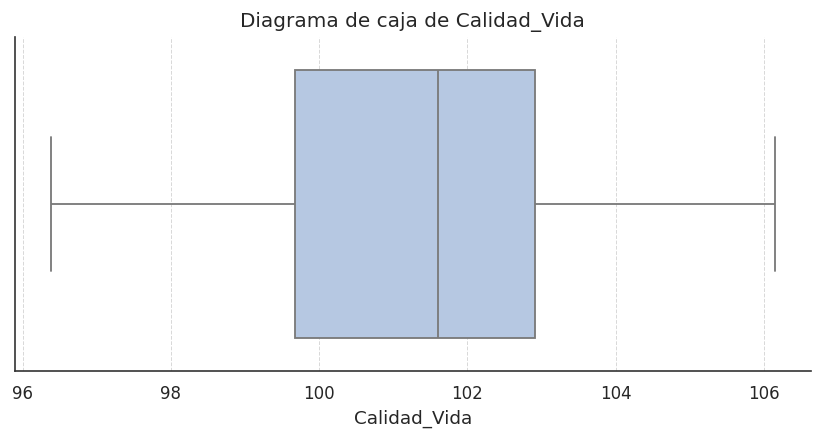

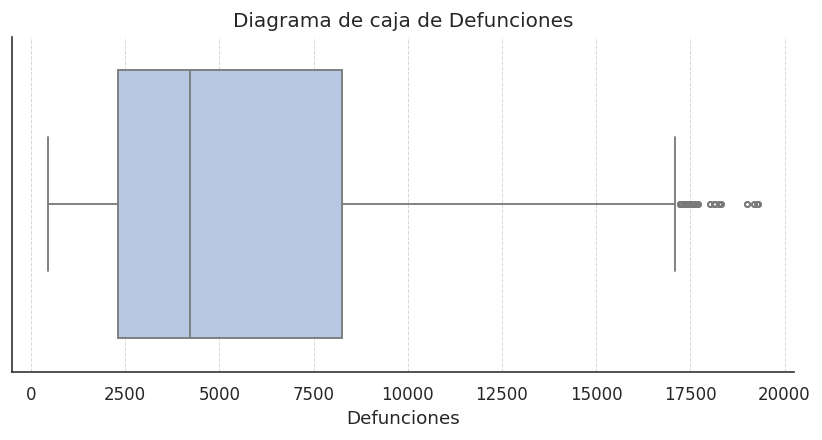

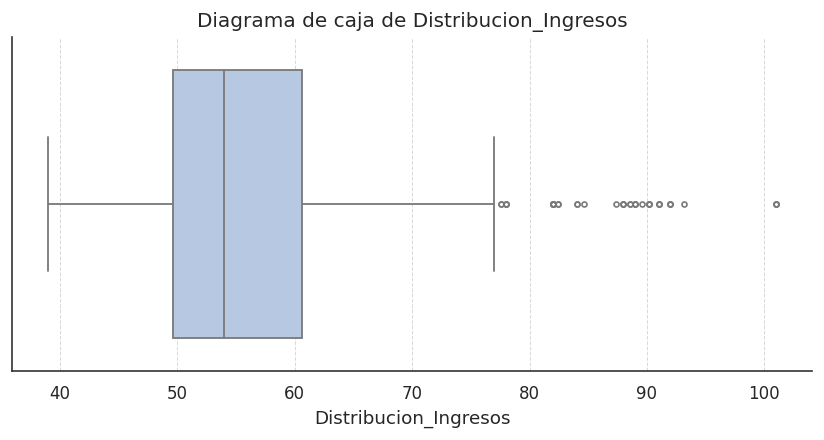

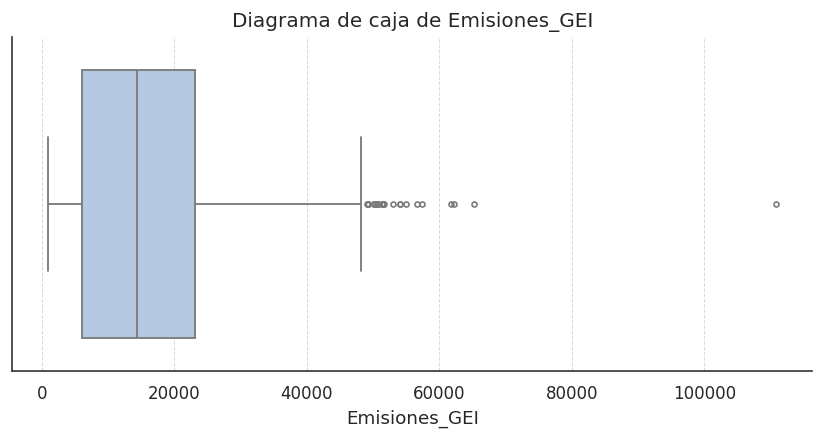

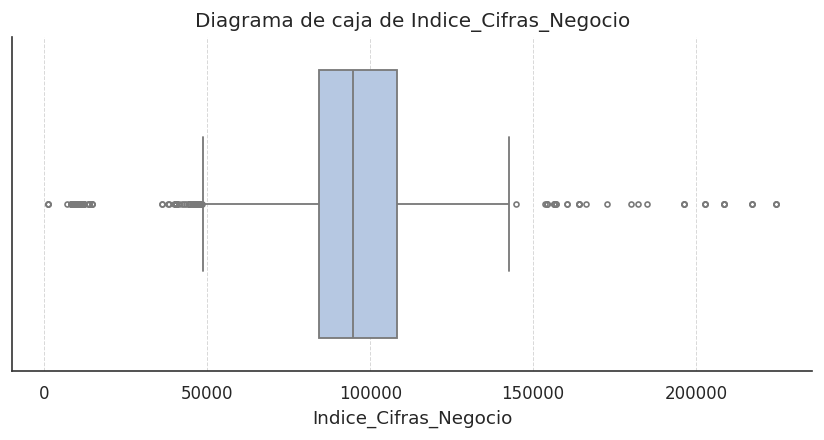

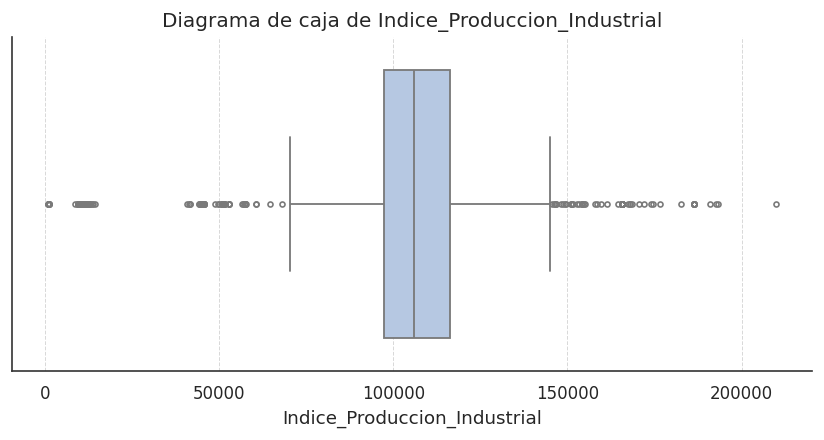

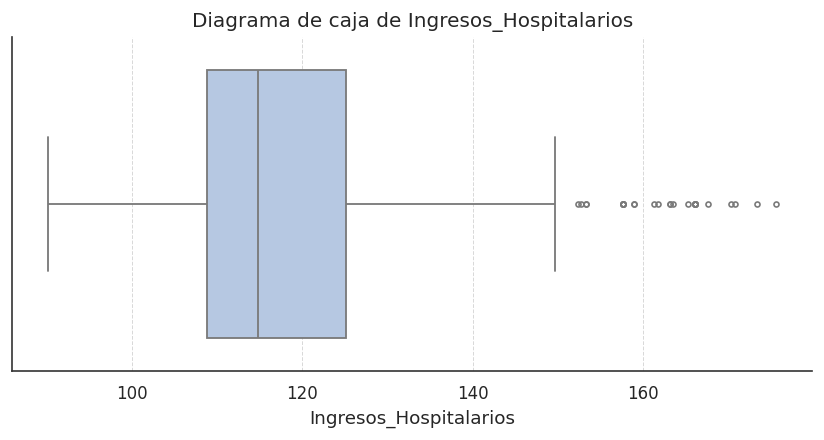

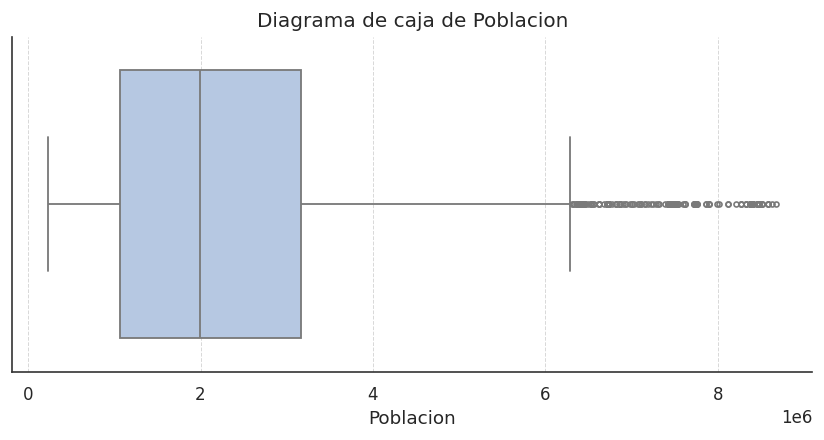

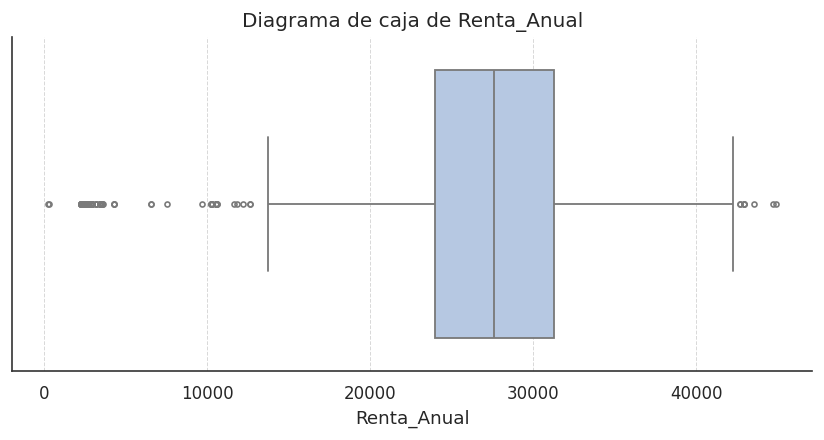

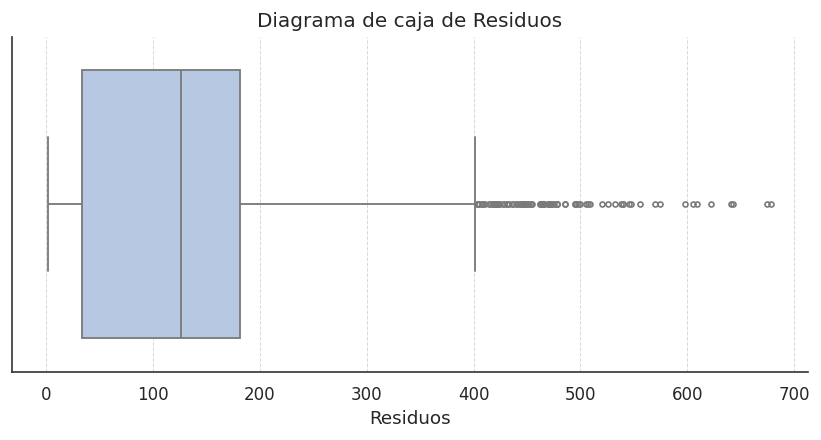

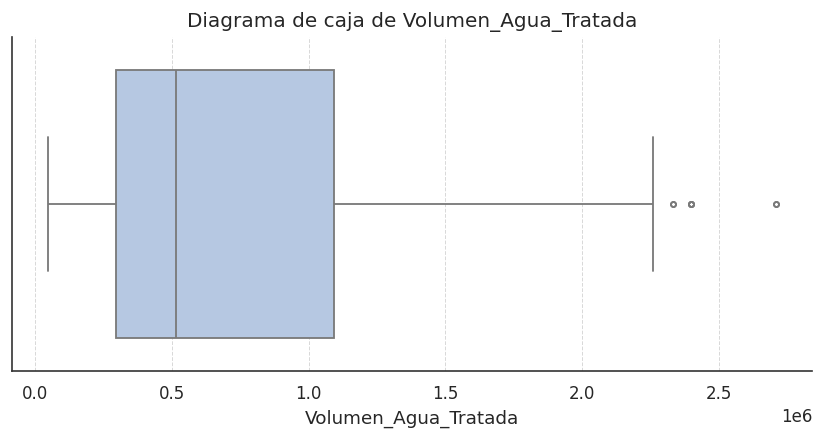

In [14]:
for col in columnas_numericas:
    plt.figure(figsize=(7, 3.8))

    sns.boxplot(
        x=df_final[col],
        color="#AFC6E9",
        linewidth=1.1,
        fliersize=3
    )

    plt.title(f"Diagrama de caja de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

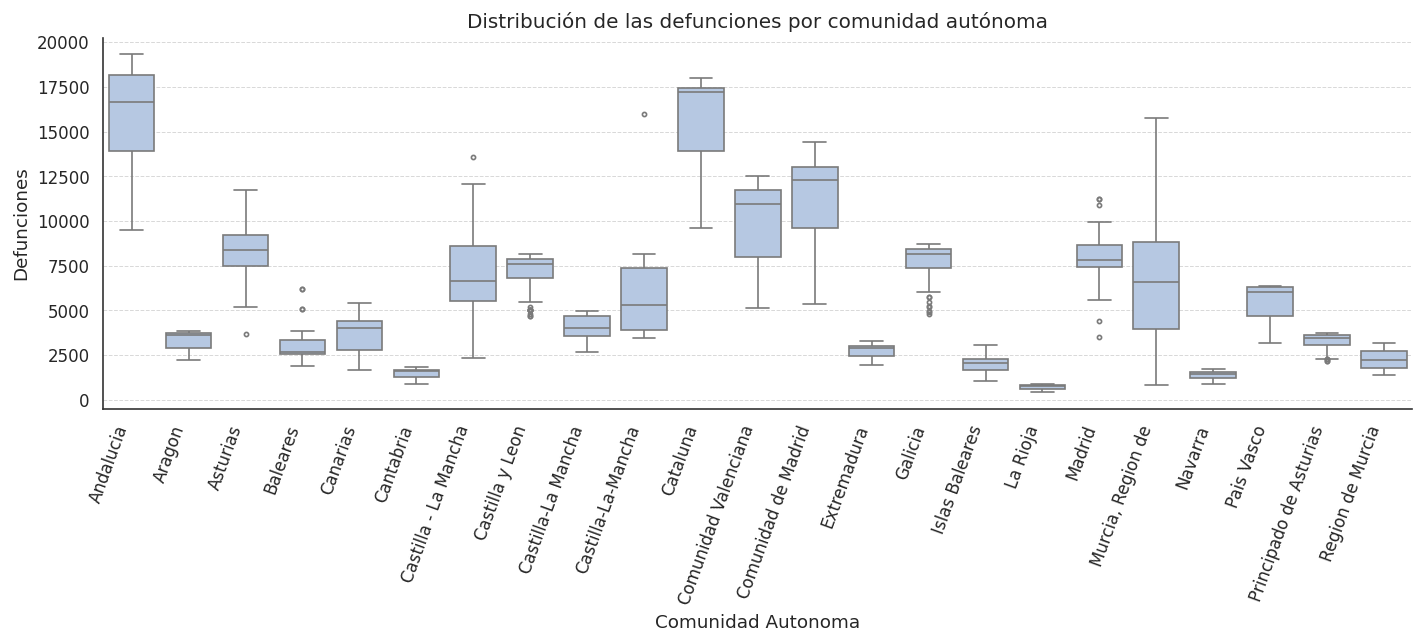

In [15]:
plt.figure(figsize=(12, 5.5))

sns.boxplot(
    data=df_final,
    x="Comunidad Autonoma",
    y="Defunciones",
    color="#AFC6E9",
    linewidth=1,
    fliersize=2.5
)

plt.xticks(rotation=70, ha="right")
plt.title("Distribución de las defunciones por comunidad autónoma")
plt.xlabel("Comunidad Autonoma")
plt.ylabel("Defunciones")
plt.tight_layout()
plt.show()


**MATRIZ DE CORRELACIÓN**

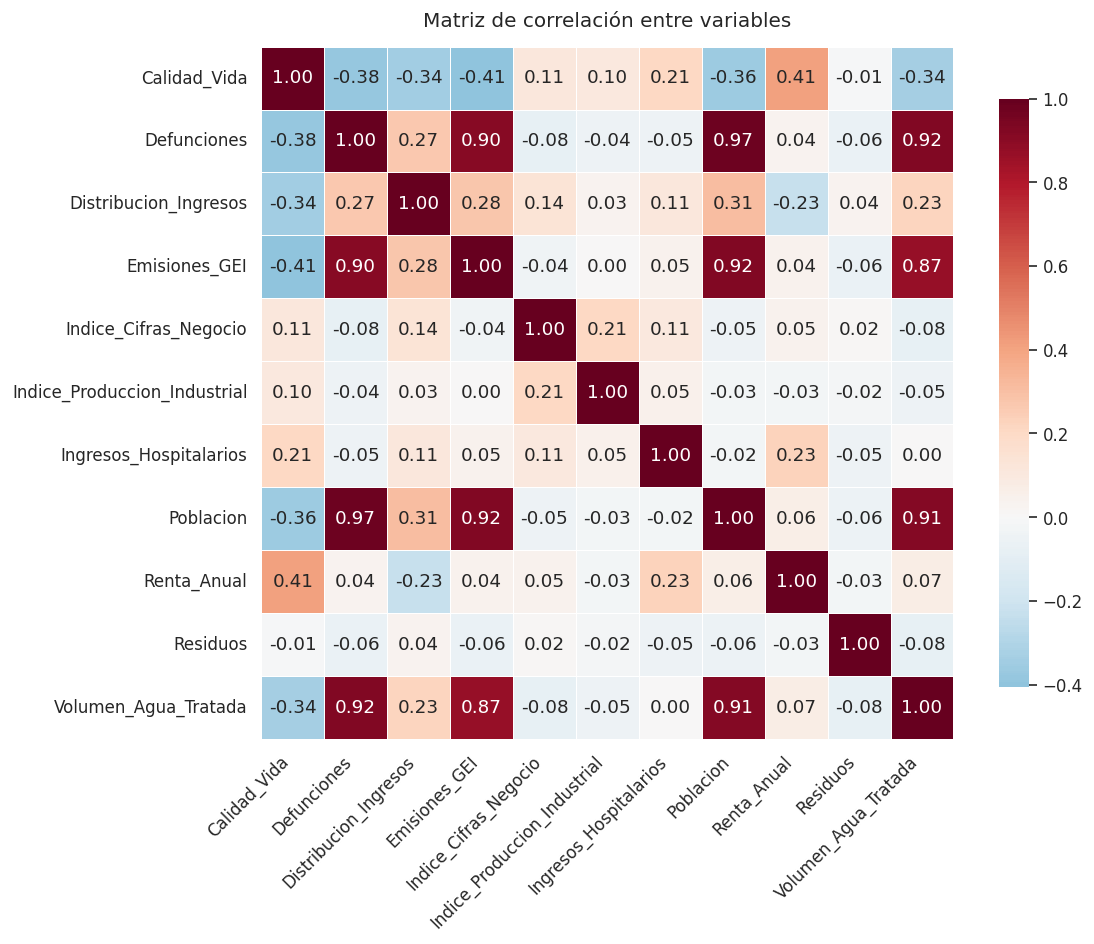

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_excluir = ["Comunidad Autonoma", "Periodo"]
df_corr = df_final.drop(columns=columnas_excluir)

matriz_corr = df_corr.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.85}
)

plt.title("Matriz de correlación entre variables", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Evolución temporal de la variable objetivo respecto a las variables que se han identificado observando la matriz de correlación: población, emisiones GEI y volumen de agua tratada.

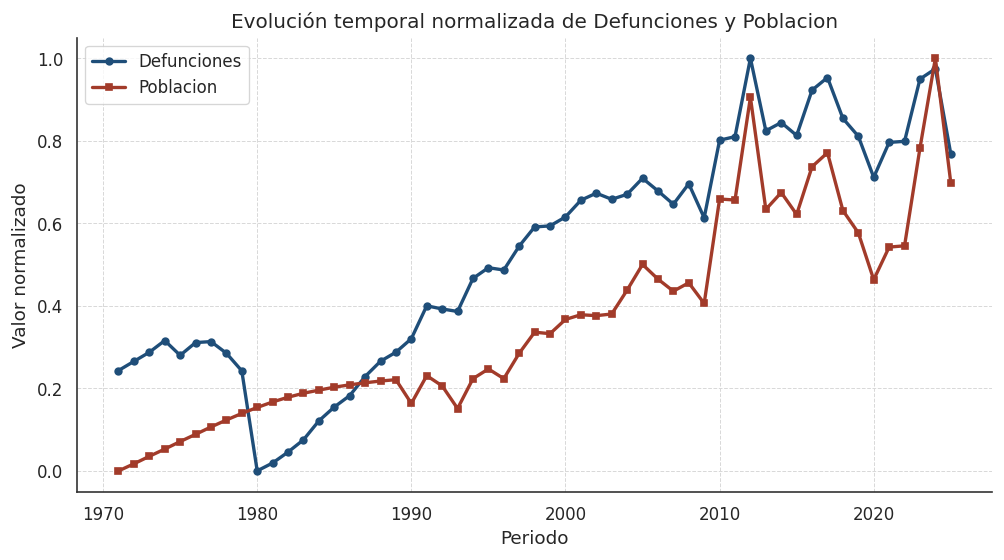

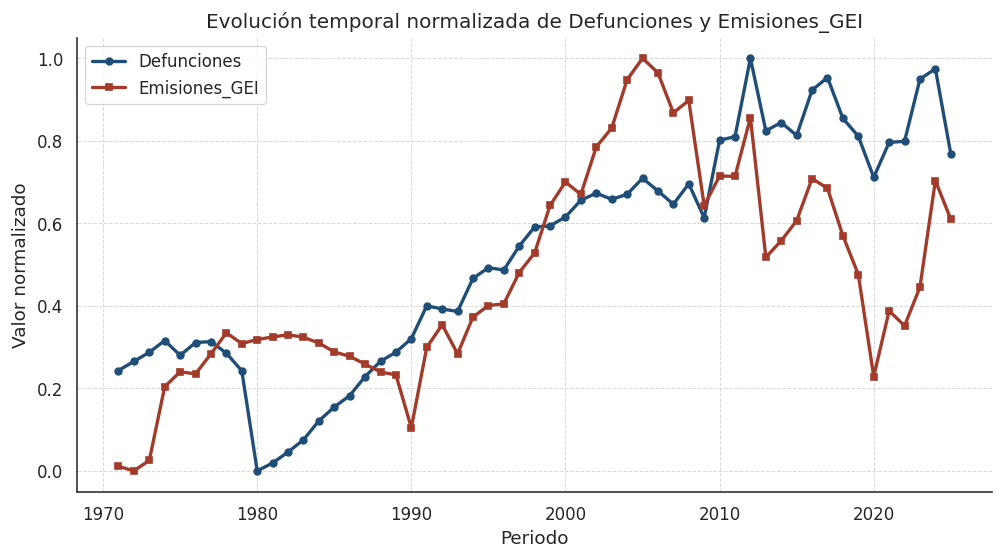

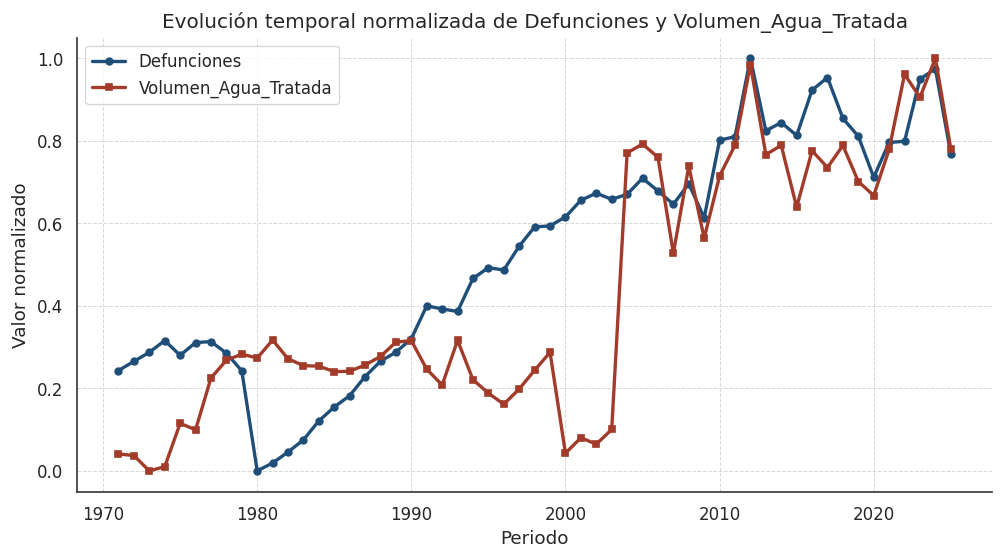

In [17]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

variables_relevantes = ["Poblacion", "Emisiones_GEI", "Volumen_Agua_Tratada"]
scaler = MinMaxScaler()

for var in variables_relevantes:
    df_temp = df_final.groupby("Periodo")[["Defunciones", var]].mean().reset_index()

    datos_norm = scaler.fit_transform(df_temp[["Defunciones", var]])
    df_norm = df_temp.copy()
    df_norm[["Defunciones", var]] = datos_norm

    plt.figure(figsize=(8.5, 4.8))

    plt.plot(
        df_norm["Periodo"], df_norm["Defunciones"],
        marker="o", markersize=4, linewidth=2,
        color="#1F4E79", label="Defunciones"
    )

    plt.plot(
        df_norm["Periodo"], df_norm[var],
        marker="s", markersize=4, linewidth=2,
        color="#A23B2A", label=var
    )

    plt.title(f"Evolución temporal normalizada de Defunciones y {var}")
    plt.xlabel("Periodo")
    plt.ylabel("Valor normalizado")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

# **ANÁLISIS DEL DATO**

En primer lugar se procederá a la carga de los datos, la separación en variables dependientes e independientes, la codificación de la variable categórica y la estandarización de las variables numéricas, así como la separación en conjunto de entrenamiento y test al 80/20.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carga datos
df = pd.read_csv("/content/drive/MyDrive/DATOS_TFG_LIMPIOS/Dataset.csv")

# Separar en X e Y
X = df.drop(columns=['Defunciones', 'Periodo'])
y = df['Defunciones']

# Codificar la variable categórica por One-Hot Encoding
X = pd.get_dummies(X, columns=['Comunidad Autonoma'], drop_first=True)

# División en Entrenamiento (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarización de variables numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Uso de GridSearchCV para elegir los mejores hiperparámetros y entranmiento de los modelos con dichos hiperparámetros en el conjunto de entrenamiento

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Definición de parámetros para la búsqueda
param_tree = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10]}
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2]}
param_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}


# 1. Árbol de Decisión
grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_tree, cv=5, scoring='r2', n_jobs=-1)
grid_tree.fit(X_train_scaled, y_train)

# 2. Random Forest
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

# 3. XGBoost
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

modelos_opt = {
    "Árbol de Decisión": grid_tree.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

print("Mejores parámetros encontrados:")
print(f"DT: {grid_tree.best_params_}")
print(f"RF: {grid_rf.best_params_}")
print(f"XGB: {grid_xgb.best_params_}")

Mejores parámetros encontrados:
DT: {'max_depth': 10, 'min_samples_split': 10}
RF: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
XGB: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


Cálculo de métricas en el conjunto de test.

In [20]:
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, max_error, explained_variance_score)

resultados_detallados = []

for nombre, modelo in modelos_opt.items():
    y_pred = modelo.predict(X_test_scaled)

    # Cálculo de métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    resultados_detallados.append({
        'Modelo': nombre,
        'R2 Score': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })

# Visualización
df_metrias_pro = pd.DataFrame(resultados_detallados)
display(df_metrias_pro.style.background_gradient(cmap='Blues').format(precision=4))

,Modelo,R2 Score,MAE,MSE,RMSE
0,Árbol de Decisión,0.9897,239.9220,251414.4318,501.4124
1,Random Forest,0.9959,184.6270,100306.7047,316.7123
2,XGBoost,0.9957,180.7789,105335.6992,324.5546


Gráficas con las variables identificadas como las más relevantes en la predicción.

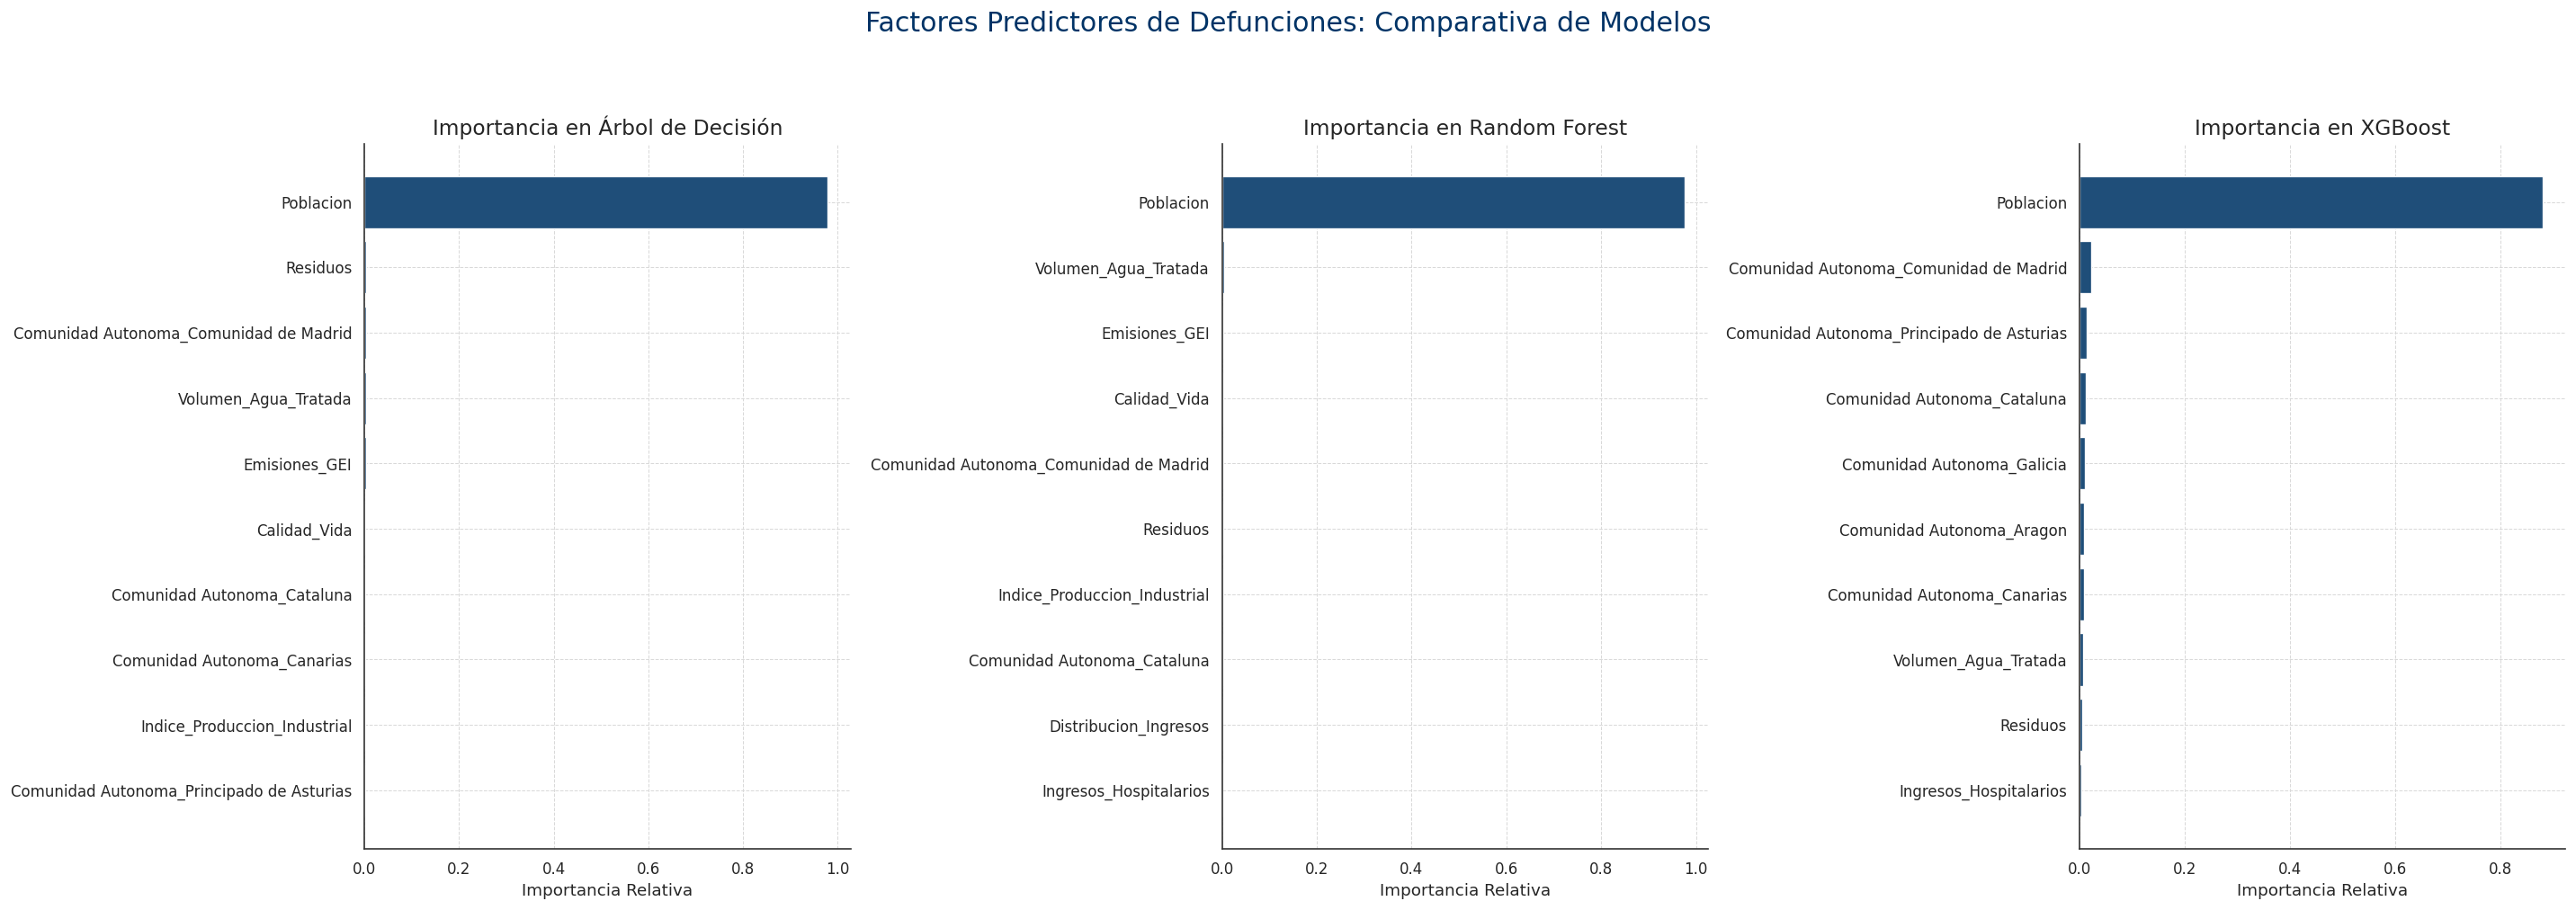

In [21]:
nombres_features = X.columns

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Factores Predictores de Defunciones: Comparativa de Modelos', fontsize=18, color='#003366', y=1.05)
colores_azul = ['#1F4E79', '#1F4E79', '#1F4E79']

for i, (nombre, modelo) in enumerate(modelos_opt.items()):
    # Extraer importancias del modelo
    importancias = modelo.feature_importances_
    indices = np.argsort(importancias)[-10:] # Top 10 variables

    axes[i].barh(range(len(indices)), importancias[indices], color=colores_azul[i])
    axes[i].set_yticks(range(len(indices)))
    axes[i].set_yticklabels([nombres_features[j] for j in indices])
    axes[i].set_title(f'Importancia en {nombre}', fontsize=14)
    axes[i].set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

Debido a que se observa que la variable de la población tiene un gran impacto respecto al resto en la variable objetivo, se procede a eliminar dicha variable y se repite todo el proceso. También se elimina la vriable de Comunidad Autónoma debido a que está altamente relacionada con el número de habitantes.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, max_error, explained_variance_score)

# Carga datos
df = pd.read_csv("/content/drive/MyDrive/DATOS_TFG_LIMPIOS/Dataset.csv")

# Eliminar columna Población
columnas_eliminar = ['Defunciones', 'Periodo', 'Comunidad Autonoma','Poblacion']
X = df.drop(columns=[c for c in columnas_eliminar if c in df.columns])
y = df['Defunciones']

# División en Entrenamiento (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarización de variables numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
# Definición de parámetros para la búsqueda
param_tree = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10]}
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2]}
param_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_tree, cv=5, scoring='r2', n_jobs=-1)
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_rf, cv=5, scoring='r2', n_jobs=-1)
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_xgb, cv=5, scoring='r2', n_jobs=-1)

grid_tree.fit(X_train_scaled, y_train)
grid_rf.fit(X_train_scaled, y_train)
grid_xgb.fit(X_train_scaled, y_train)

modelos_reducidos = {
    "Árbol de Decisión": grid_tree.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

,Modelo,R2 Score,MAE,MSE,RMSE
0,Árbol de Decisión,0.983435,268.080039,403519.682987,635.231991
1,Random Forest,0.987557,282.136737,303114.586734,550.558432
2,XGBoost,0.988715,280.312812,274901.347508,524.310354


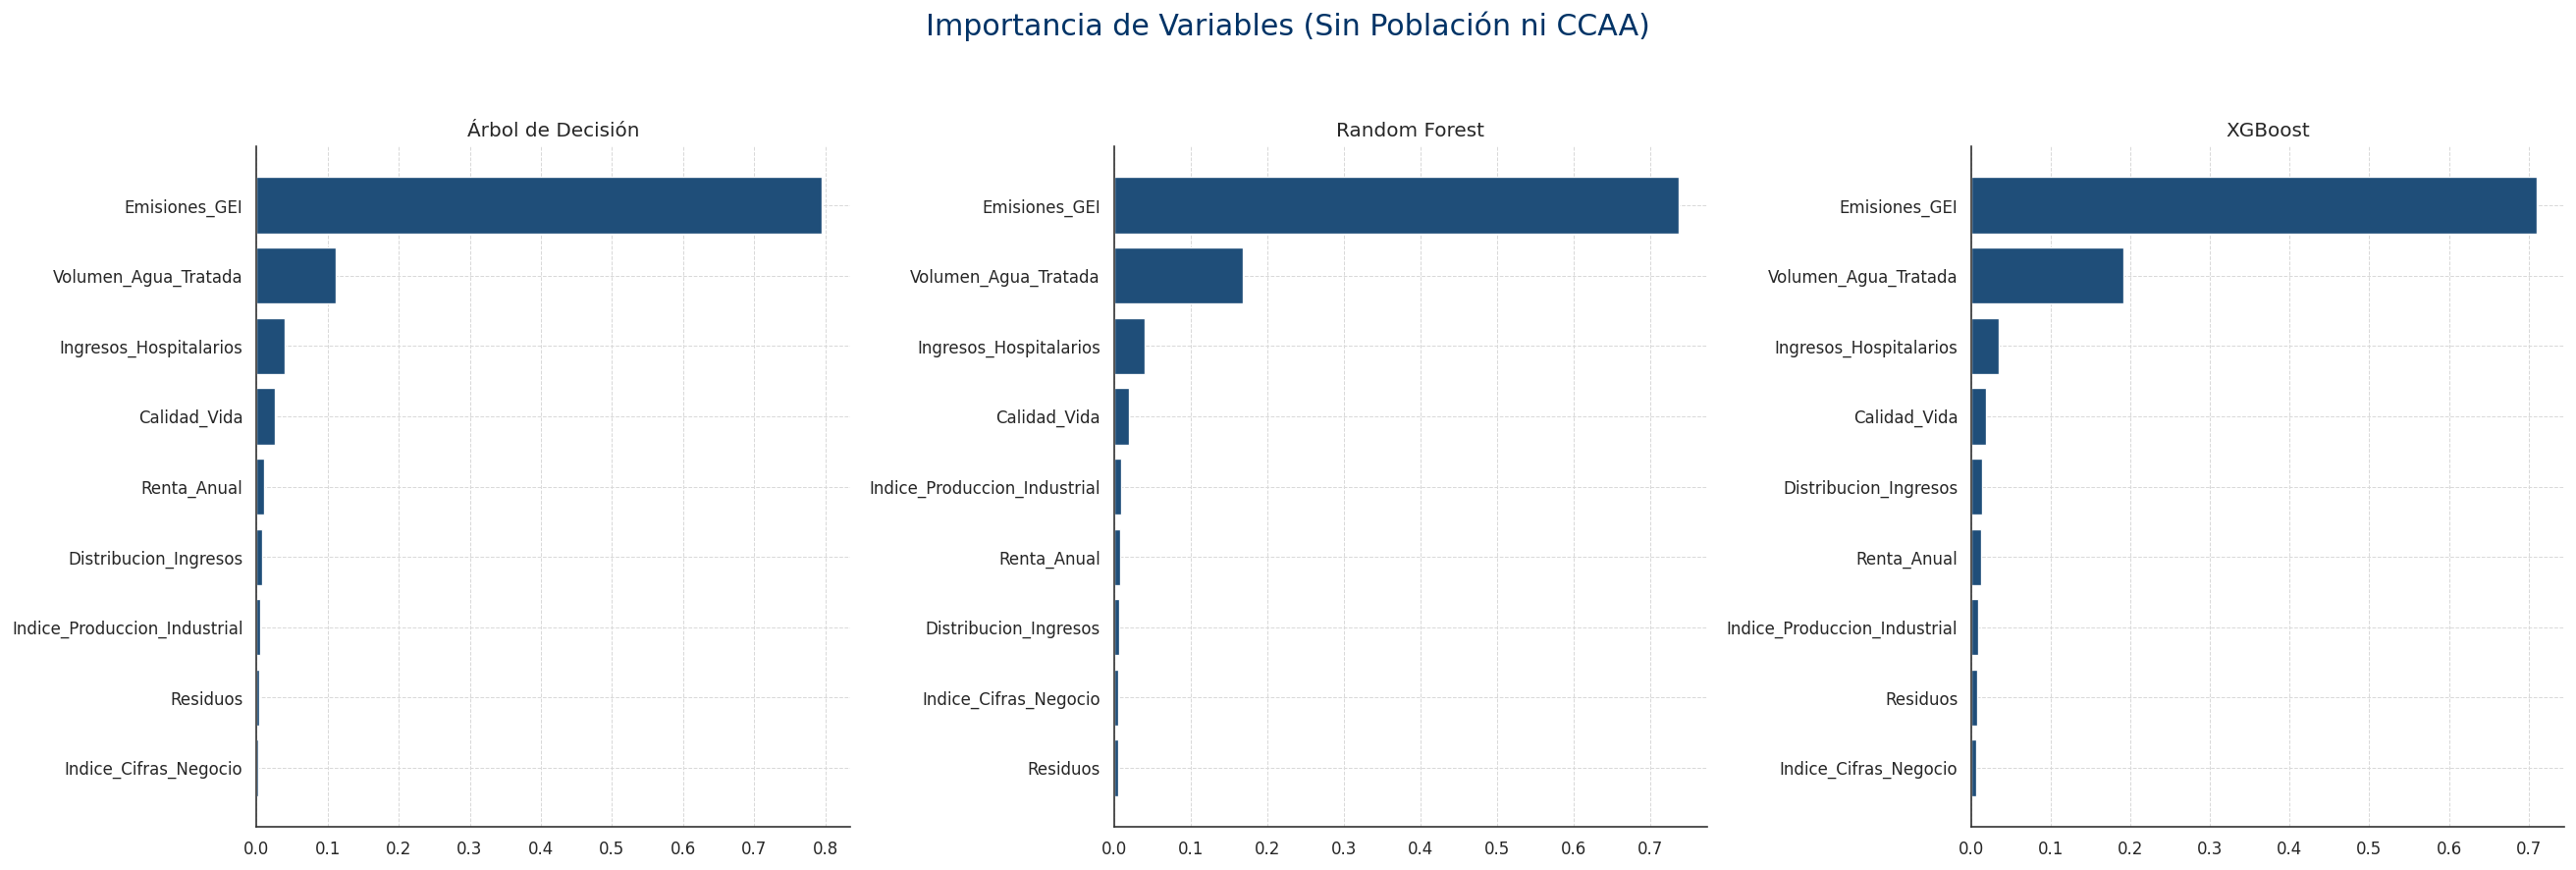

In [28]:
# Métricas
resultados = []
for nombre, modelo in modelos_reducidos.items():
    y_pred = modelo.predict(X_test_scaled)
    resultados.append({
        'Modelo': nombre,
        'R2 Score': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })

df_resumen = pd.DataFrame(resultados)
display(df_resumen.style.background_gradient(cmap='Blues'))

# Gráfico importancia de variables
features = X.columns
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Importancia de Variables (Sin Población ni CCAA)', fontsize=18, color='#003366', y=1.05)
colores_azul = ['#1F4E79', '#1F4E79', '#1F4E79']

for i, (nombre, modelo) in enumerate(modelos_reducidos.items()):
    imp = modelo.feature_importances_
    idx = np.argsort(imp)[-10:] # Top 10
    axes[i].barh(range(len(idx)), imp[idx], color=colores_azul[i])
    axes[i].set_yticks(range(len(idx)))
    axes[i].set_yticklabels([features[j] for j in idx])
    axes[i].set_title(nombre)

plt.tight_layout()
plt.show()

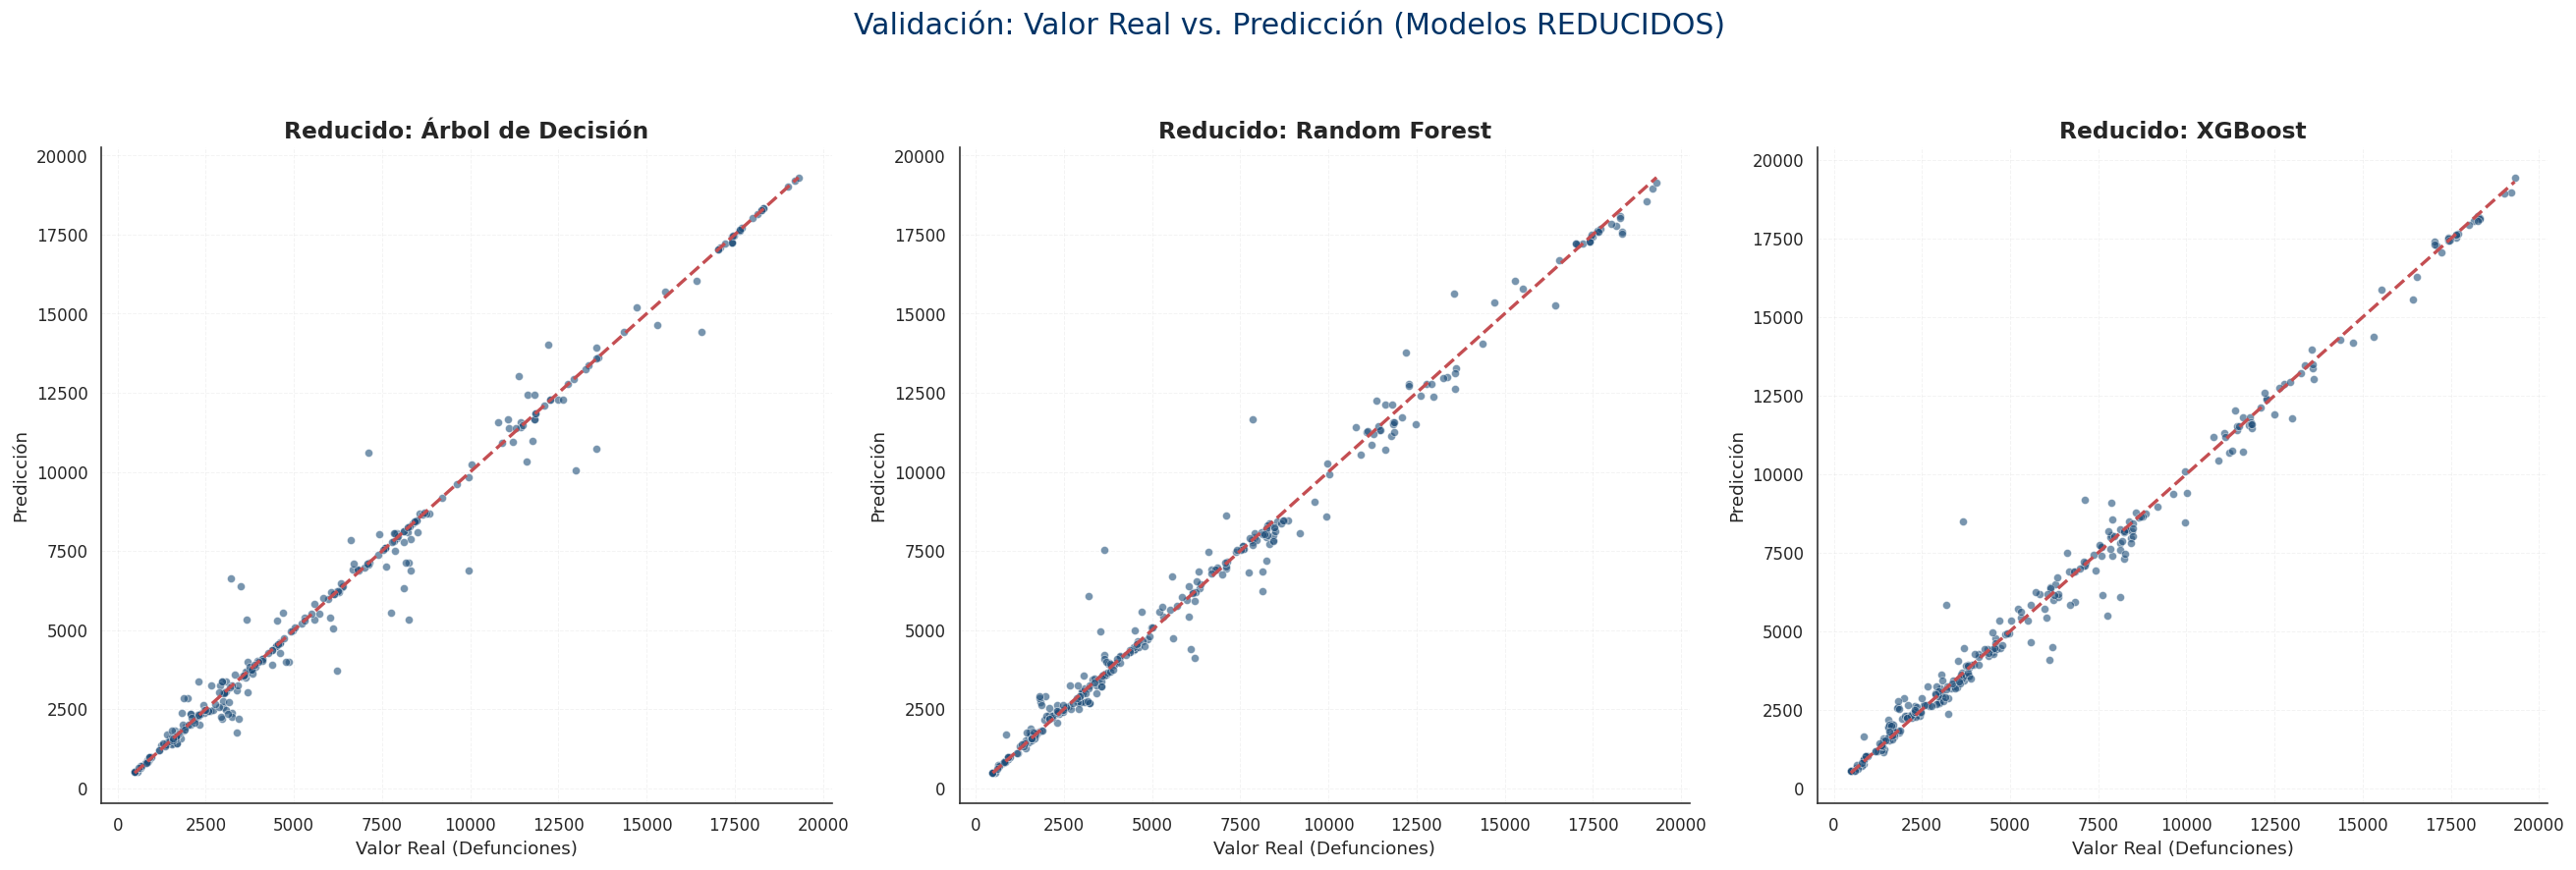

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

punto_color = '#1F4E79'

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Validación: Valor Real vs. Predicción (Modelos REDUCIDOS)', fontsize=18, color='#003366', y=1.05)

modelos_r = [grid_tree.best_estimator_, grid_rf.best_estimator_, grid_xgb.best_estimator_]
nombres_r = ["Árbol de Decisión", "Random Forest", "XGBoost"]

for i in range(3):
    y_pred = modelos_r[i].predict(X_test_scaled)

    # Gráfico ajuste regresiones
    sns.scatterplot(x=y_test, y=y_pred, ax=axes[i], color=punto_color, alpha=0.6)

    # Línea de identidad (diagonal roja)
    lims = [y_test.min(), y_test.max()]
    axes[i].plot(lims, lims, 'r--', lw=2, label='Referencia')

    axes[i].set_title(f'Reducido: {nombres_r[i]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Valor Real (Defunciones)')
    axes[i].set_ylabel('Predicción')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()